In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [8]:
url = "https://raw.githubusercontent.com/amatussabur21-dotcom/hhs-care-demand-forecast/main/HHS_Unaccompanied_Alien_Children_Program.csv"
df = pd.read_csv(url)


In [9]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [10]:
df.shape

(1170, 6)

In [11]:
df.columns

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


# ***1.  Time Series Preparation***

In [13]:
# convert Date type
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    object        
 5   Children discharged from HHS Care                720 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 55.0+ KB


In [15]:
df = df.sort_values(by='Date')

In [16]:
df.set_index('Date', inplace = True)

In [17]:
df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,"6,566",436.0
2023-01-22,32.0,49.0,39.0,"7,122",227.0
2023-01-23,32.0,50.0,39.0,"7,280",181.0
2023-01-24,47.0,42.0,47.0,"7,433",175.0
2023-01-25,20.0,22.0,41.0,"7,538",180.0


In [18]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [19]:
#check if dates are daily or not in next 2 cells

df.index.min(), df.index.max()


(Timestamp('2023-01-12 00:00:00'), Timestamp('2025-12-21 00:00:00'))

In [20]:
# df = df.asfreq('D')  error shows that date has duplicates values


In [21]:
# check duplicates first
df.index.duplicated().sum()

np.int64(449)

In [22]:
# combine those rows of same date or index

df = df.groupby(df.index).sum()

In [23]:
# now we will apply daily date series

df = df.asfreq('D')

In [24]:
df.head()
# some rows ahve NaN means misssing data

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,"6,566",436.0
2023-01-13,NaN,NaN,NaN,NaN,NaN
2023-01-14,NaN,NaN,NaN,NaN,NaN
2023-01-15,NaN,NaN,NaN,NaN,NaN
2023-01-16,NaN,NaN,NaN,NaN,NaN


**Handling missing values using linear interplolation**

In [25]:
df = df.interpolate(method='linear')

/tmp/ipykernel_491/2145716054.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear')


In [26]:
df.head()
# done

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,"6,566",436.0
2023-01-13,32.9,52.6,34.5,NaN,415.1
2023-01-14,32.8,52.2,35.0,NaN,394.2
2023-01-15,32.7,51.8,35.5,NaN,373.3
2023-01-16,32.6,51.4,36.0,NaN,352.4


**Time-Series Decomposition :**

In [27]:
!pip install statsmodels

In [28]:
df['Children in HHS Care'] = df['Children in HHS Care'].astype(str).str.replace(',', '', regex=True)
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'], errors='coerce')

#  I've updated the code to use errors='coerce' in pd.to_numeric. This will convert any unparseable strings (like 'nan')
# into proper numerical NaN values, allowing the interpolate method to fill them correctly.
# Re-interpolate the dataframe to fill any NaNs that might exist in the newly numeric column.
# The previous interpolation might not have fully converted or handled NaNs in object-type columns correctly.
df = df.interpolate(method='linear')



In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose

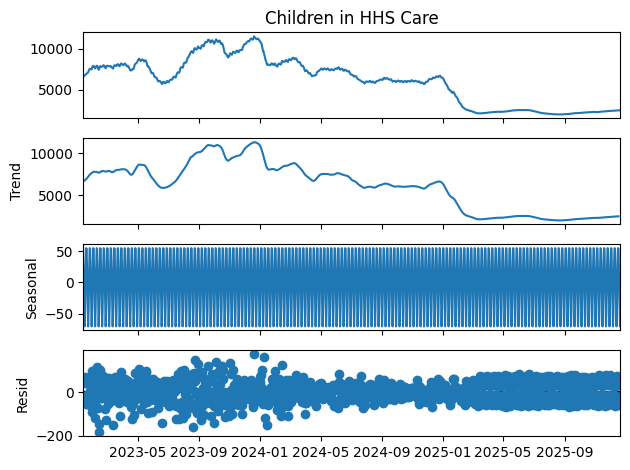

In [30]:
result = seasonal_decompose(df['Children in HHS Care'], model='additive', period=7)
fig = result.plot()
plt.show()

# ***2. Feature Engineering for Forecasting***

In [31]:
# creating lag features

df['lag_1'] = df['Children in HHS Care'].shift(1)
df['lag_2'] = df['Children in HHS Care'].shift(7)
df['lag_3'] = df['Children in HHS Care'].shift(14)

df.head(15)

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,lag_1,lag_2,lag_3
Date,,,,,,,,
2023-01-12,33.00,53.00,34.0,6566.0,436.00,NaN,NaN,NaN
2023-01-13,32.90,52.60,34.5,6621.6,415.10,6566.0,NaN,NaN
2023-01-14,32.80,52.20,35.0,6677.2,394.20,6621.6,NaN,NaN
2023-01-15,32.70,51.80,35.5,6732.8,373.30,6677.2,NaN,NaN
2023-01-16,32.60,51.40,36.0,6788.4,352.40,6732.8,NaN,NaN
2023-01-17,32.50,51.00,36.5,6844.0,331.50,6788.4,NaN,NaN
2023-01-18,32.40,50.60,37.0,6899.6,310.60,6844.0,NaN,NaN
2023-01-19,32.30,50.20,37.5,6955.2,289.70,6899.6,6566.0,NaN
2023-01-20,32.20,49.80,38.0,7010.8,268.80,6955.2,6621.6,NaN


In [32]:
# drop rows containing nan
df = df.dropna()

In [33]:
df.shape  #remaining rows

(1061, 8)

In [34]:
# creating rolling features

# rolling mean/average - to know direction over last 7 days and last 14 days means short-term trend
df['roll_mean_7'] = df['Children in HHS Care'].rolling(window = 7).mean()
df['roll_mean_14'] = df['Children in HHS Care'].rolling(window = 14).mean()

# rolling std - to know how unstable our system were over last 7 and 14 days
df['roll_std_7'] = df['Children in HHS Care'].rolling(window = 7).std()
df['roll_std_14'] = df['Children in HHS Care'].rolling(window = 14).std()

# drop rows having Nan
df = df.dropna()
df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,lag_1,lag_2,lag_3,roll_mean_7,roll_mean_14,roll_std_7,roll_std_14
Date,,,,,,,,,,,,
2023-02-08,93.000000,196.000000,169.0,7915.0,317.0,7855.0,7903.000000,7538.0,7774.285714,7704.000000,118.279554,162.342323
2023-02-09,124.000000,234.000000,161.0,7908.0,353.0,7915.0,7879.000000,7521.5,7778.428571,7731.607143,122.973305,161.782137
2023-02-10,113.333333,223.666667,165.0,7750.0,341.0,7908.0,7781.333333,7505.0,7773.952381,7749.107143,123.419404,148.052740
2023-02-11,102.666667,213.333333,169.0,7592.0,329.0,7750.0,7683.666667,7488.5,7760.857143,7756.500000,138.533304,136.143699
2023-02-12,92.000000,203.000000,173.0,7434.0,317.0,7592.0,7586.000000,7472.0,7739.142857,7753.785714,177.063481,142.483264


In [35]:
# net pressure indicator feature
df['net_flow'] = (df['Children transferred out of CBP custody'] - df['Children discharged from HHS Care'])

In [36]:
# Calender Effects

df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)


In [37]:
!pip install holidays

In [38]:
# holiday proxy
import holidays
us_holidays = holidays.US()
df['is_holiday'] = df.index.isin(us_holidays).astype(int)

In [39]:
# extra cal signals
df['is_month_start'] = df.index.is_month_start.astype(int)
df['is_month_end'] = df.index.is_month_end.astype(int)

In [40]:
df = df.dropna()
df.head(7)

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,lag_1,lag_2,lag_3,roll_mean_7,roll_mean_14,roll_std_7,roll_std_14,net_flow,day_of_week,month,is_weekend,is_holiday,is_month_start,is_month_end
Date,,,,,,,,,,,,,,,,,,,
2023-02-08,93.000000,196.000000,169.0,7915.0,317.0,7855.0,7903.000000,7538.0,7774.285714,7704.000000,118.279554,162.342323,-148.0,2,2,0,0,0,0
2023-02-09,124.000000,234.000000,161.0,7908.0,353.0,7915.0,7879.000000,7521.5,7778.428571,7731.607143,122.973305,161.782137,-192.0,3,2,0,0,0,0
2023-02-10,113.333333,223.666667,165.0,7750.0,341.0,7908.0,7781.333333,7505.0,7773.952381,7749.107143,123.419404,148.052740,-176.0,4,2,0,0,0,0
2023-02-11,102.666667,213.333333,169.0,7592.0,329.0,7750.0,7683.666667,7488.5,7760.857143,7756.500000,138.533304,136.143699,-160.0,5,2,1,0,0,0
2023-02-12,92.000000,203.000000,173.0,7434.0,317.0,7592.0,7586.000000,7472.0,7739.142857,7753.785714,177.063481,142.483264,-144.0,6,2,1,0,0,0
2023-02-13,186.000000,259.000000,172.0,7483.0,244.0,7434.0,7720.000000,7743.0,7705.285714,7735.214286,202.207578,159.879581,-72.0,0,2,0,0,0,0
2023-02-14,154.000000,225.000000,220.0,7794.0,223.0,7483.0,7855.000000,7803.0,7696.571429,7734.571429,195.896109,159.603913,-3.0,1,2,0,0,0,0


# ***3. TRAIN-TEST STRATEGY***

**Strict Time-based splitting**

In [41]:
# strict time-based split

# define features & target
x = df.drop(columns=['Children in HHS Care'])
y = df['Children in HHS Care']

# 80% trian, 20% test
split = int(len(df) * 0.8)

x_train = x.iloc[:split]
x_test = x.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

y_pred =  model.predict(x_test)

mae_strict = mean_absolute_error(y_test, y_pred)
print("Strict Split MAE:", mae_strict)

Strict Split MAE: 38.047211904761724


**Walk-forward Validation splitting**

In [42]:
# Walk-forward Validation - stimulates real world forecasting

predictions = []
actuals = []


for i in range(split, len(df)):
  model = RandomForestRegressor(n_estimators = 30, random_state=42)

  x_train_wf = x.iloc[:i]
  y_train_wf = y.iloc[:i]

  x_test_wf = x.iloc[i:i+1]
  y_test_wf = y.iloc[i:i+1]

  model.fit(x_train_wf, y_train_wf)

  pred = model.predict(x_test_wf)[0]

  predictions.append(pred)
  actuals.append(y_test_wf.values[0])


mae_wf = mean_absolute_error(actuals, predictions)
print("Walk Forward MAE:", mae_wf)

Walk Forward MAE: 8.364382464096755


**Multi-Horizon Evaluation**

In [43]:
df['target_1'] = df['Children in HHS Care'].shift(-1)
df['target_7'] = df['Children in HHS Care'].shift(-7)
df['target_14'] = df['Children in HHS Care'].shift(-14)

df = df.dropna()

*Evaluation :*

In [44]:
features = [
    'lag_1', 'lag_2', 'lag_3',
    'roll_mean_7', 'roll_std_7',
    'roll_mean_14', 'roll_std_14',
    'net_flow',
    'day_of_week', 'month',
    'is_weekend', 'is_holiday',
    'is_month_start', 'is_month_end'
]

X = df[features]

In [45]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

In [46]:
horizons = {
    "1_day": "target_1",
    "7_day": "target_7",
    "14_day": "target_14"
}

for name, target in horizons.items():

    y = df[target]

    y_train = y.iloc[:split]
    y_test  = y.iloc[split:]

    model = RandomForestRegressor(n_estimators=50, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    print(f"{name} Forecast MAE: {mae}")

1_day Forecast MAE: 66.8228985507246
7_day Forecast MAE: 92.41858293075687
14_day Forecast MAE: 174.72816747181963


**VISUALIZE PREDICTIONS :**

In [47]:
# 1-day forecast only(for plotting)

target = 'target_1'

x = df[features]
y = df[target]

split = int(len(df) * 0.8)

x_train = x.iloc[:split]
x_test = x.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

model = RandomForestRegressor(n_estimators = 100, random_state = 42)
model.fit(x_train, y_train)

preds =  model.predict(x_test)

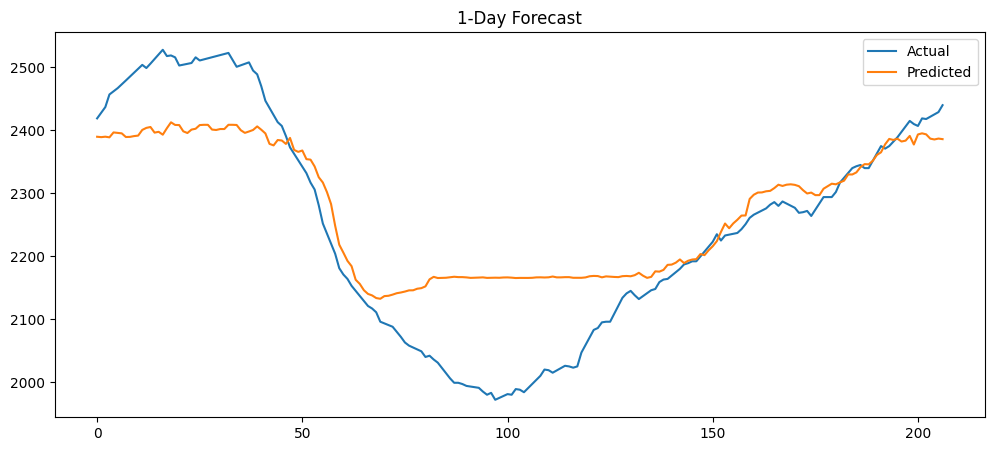

In [48]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(preds, label="Predicted")
plt.legend()
plt.title("1-Day Forecast")
plt.show()

***Conclusion ::***
The 1-day forecast model successfully captures overall trend dynamics. While short-term fluctuations are slightly smoothed, the model maintains stable predictive behavior with low average error (~67 units), indicating strong short-term forecasting capability.

In [49]:
# 7-day forecast only (for plotting)

target = 'target_7'

X = df[features]
y = df[target]

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds_7 = model.predict(X_test)

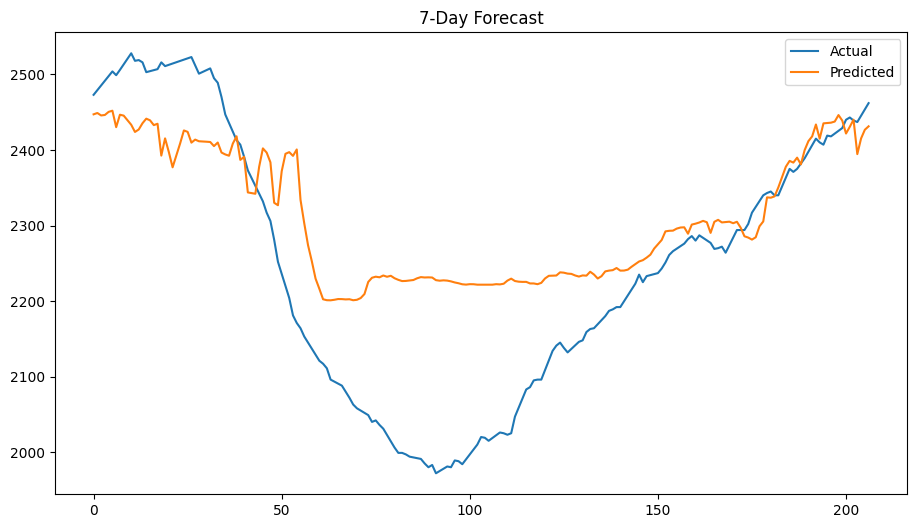

In [50]:
plt.figure(figsize=(11,6))
plt.plot(y_test.values, label="Actual")
plt.plot(preds_7, label="Predicted")
plt.legend()
plt.title("7-Day Forecast")
plt.show()

***Conclusion ::***
The 7-day forecast maintains trend alignment but exhibits increased smoothing and lag at turning points compared to the 1-day model. This behavior is expected due to higher uncertainty in medium-term predictions, reflected in the increased MAE (~92).

In [51]:
# 14-day forecast only (for plotting)

target = 'target_14'

X = df[features]
y = df[target]

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds_14 = model.predict(X_test)

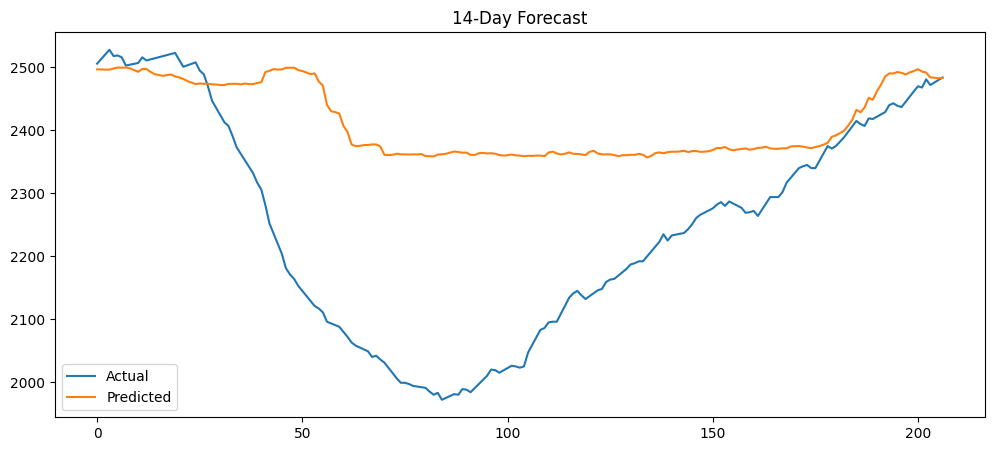

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(preds_14, label="Predicted")
plt.legend()
plt.title("14-Day Forecast")
plt.show()

***Conclusion ::***
The 14-day forecast shows that the model successfully captures the overall trend of care load changes but struggles to accurately predict sharp fluctuations.

Key observations:

• The predicted line is smoother than the actual values
• The model underestimates sudden drops
• Recovery trends are captured but with noticeable lag
• Error is visibly larger compared to 1-day and 7-day forecasts

This behavior is expected in long-horizon forecasting because:

Uncertainty increases as the prediction window expands

The model relies more on historical patterns

Sudden shocks are difficult to anticipate 14 days in advance

# ***4. FORECASTING MODELS***

# **Baseline Models**

1.   naive persistence model
2.   Moving average forecast



In [53]:
# # naive 1day ahead forecast using strict split

# # predictions = previous day's actual values
# # ex prdection for day 2 = day 1 value
# y_pred_naive = y_test.shift(1)

# # remove the first value that becomes NaN after shifting
# y_pred_naive = y_pred_naive.dropna()

# # ensures y_actual & y_pred_naive have same dates
# y_actual = y_test.loc[y_pred_naive.index]

# # import mae func
# from sklearn.metrics import mean_absolute_error

# # calculate mae
# mae_naive_1 = mean_absolute_error(y_actual, y_pred_naive)
# rmse_naive_1 = np.sqrt(mean_squared_error(y_actual, y_pred_naive))
# mape_naive_1 = np.mean(
#     np.abs((np.array(y_actual) - np.array(y_pred_naive))
#            / np.array(y_actual))
# ) * 100

# print("Naive 1_Day MAE :", mae_naive_1)
# print("Naive 1_Day RMSE :", rmse_naive_1)
# print("Naive 1_Day MAPE:", mape_naive_1)

In [54]:
# naive 1day ahead forecast using walk-forward
from sklearn.metrics import mean_absolute_error

# convert training data to list - to keep adding new values 1 by 1
history = list(y_train)

# empty list of predictions
predictions = []

# start walk-frwd loop
for t in range(len(y_test)):
  yhat = history[-1]         # tommorow = today
  predictions.append(yhat)
  history.append(y_test.iloc[t]) #adding the actual real value to taining set

mae_naive_wf_1 = mean_absolute_error(y_test, predictions)
rmse_naive_wf_1 = np.sqrt(mean_squared_error(y_test, predictions))
mape_naive_wf_1 = np.mean(
    np.abs((np.array(y_test) - np.array(predictions))
           / np.array(y_test))
) * 100

print("Naive Walk-Forward 1-day MAE :", mae_naive_wf_1)
print("Naive Walk-Forward 1-day RMSE :", rmse_naive_wf_1)
print("Naive Walk-Forward 1-day MAPE :", mape_naive_wf_1)



Naive Walk-Forward 1-day MAE : 6.671497584541063
Naive Walk-Forward 1-day RMSE : 8.306063040322634
Naive Walk-Forward 1-day MAPE : 0.2967895389799285


In [55]:
# naive 7day ahead forecast using walk-forward
history = list(y_train)
predictions_7 = []

for t in range(len(y_test)):

  if len(history) >= 7:
    yhat = history[-7]   #value of 7day ago
  else:
    yhat = history[-1]

  predictions_7.append(yhat)
  history.append(y_test.iloc[t])

mae_naive_wf_7 = mean_absolute_error(y_test, predictions_7)
rmse_naive_wf_7 = np.sqrt(mean_squared_error(y_test, predictions_7))
mape_naive_wf_7 = np.mean(
    np.abs((np.array(y_test) - np.array(predictions_7))
           / np.array(y_test))
) * 100

print("Naive Walk-Forward 7-day MAE :", mae_naive_wf_7)
print("Naive Walk-Forward 7-day RMSE :", rmse_naive_wf_7)
print("Naive Walk-Forward 7-day MAPE :", mape_naive_wf_7)


Naive Walk-Forward 7-day MAE : 37.27007131354957
Naive Walk-Forward 7-day RMSE : 45.794784424647766
Naive Walk-Forward 7-day MAPE : 1.6717437928950647


In [56]:
# naive 7day ahead forecast using walk-forward
history = list(y_train)
predictions_14 = []

for t in range(len(y_test)):

  if len(history) >= 14:
    yhat = history[-14]   #value of 14day ago
  else:
    yhat = history[-1]

  predictions_14.append(yhat)
  history.append(y_test.iloc[t])

mae_naive_wf_14 = mean_absolute_error(y_test, predictions_14)
rmse_naive_wf_14 = np.sqrt(mean_squared_error(y_test, predictions_14))
mape_naive_wf_14 = np.mean(
    np.abs((np.array(y_test) - np.array(predictions_14))
           / np.array(y_test))
) * 100
print("Naive Walk-Forward 14-day MAE :", mae_naive_wf_14)
print("Naive Walk-Forward 14-day RMSE :", rmse_naive_wf_14)
print("Naive Walk-Forward 14-day MAPE :", mape_naive_wf_14)



Naive Walk-Forward 14-day MAE : 71.53853232114102
Naive Walk-Forward 14-day RMSE : 87.56705901422046
Naive Walk-Forward 14-day MAPE : 3.225936039251245


In [57]:
# ===============================
# NAIVE HORIZON METRICS
# ===============================

naive_horizon_metrics = {
    "1-Day": {
        "MAE": mae_naive_wf_1,
        "RMSE": rmse_naive_wf_1,
        "MAPE": mape_naive_wf_1
    },
    "7-Day": {
        "MAE": mae_naive_wf_7,
        "RMSE": rmse_naive_wf_7,
        "MAPE": mape_naive_wf_7
    },
    "14-Day": {
        "MAE": mae_naive_wf_14,
        "RMSE": rmse_naive_wf_14,
        "MAPE": mape_naive_wf_14
    }
}

print("\nNaive Horizon Metrics:")
for h, m in naive_horizon_metrics.items():
    print(h, ":", m)


Naive Horizon Metrics:
1-Day : {'MAE': 6.671497584541063, 'RMSE': np.float64(8.306063040322634), 'MAPE': np.float64(0.2967895389799285)}
7-Day : {'MAE': 37.27007131354957, 'RMSE': np.float64(45.794784424647766), 'MAPE': np.float64(1.6717437928950647)}
14-Day : {'MAE': 71.53853232114102, 'RMSE': np.float64(87.56705901422046), 'MAPE': np.float64(3.225936039251245)}


*con: *

| Horizon | Naïve Walk-Forward MAE |
| ------- | ---------------------- |
| 1-Day   | ~6.67                  |
| 7-Day   | ~37.27                 |
| 14-Day  | ~71.54                 |

Baseline naïve forecasts show strong short-term predictability (MAE ≈ 6.7) with error increasing progressively for 7-day (≈37.3) and 14-day (≈71.5) horizons, reflecting growing forecast uncertainty over longer intervals.


In [58]:
# moving avg 1-day forcast using walk-frwd
history = list(y_train)
predictions_ma = []
window = 7   #7-day moving average

for t in range(len(y_test)):

  if len(history) >= window:
    yhat = np.mean(history[-window:])
  else:
    yhat = np.mean(history)

  predictions_ma.append(yhat)
  history.append(y_test.iloc[t])

mae_ma_1 = mean_absolute_error(y_test, predictions_ma)
rmse_ma_1 = np.sqrt(mean_squared_error(y_test, predictions_ma))
mape_ma_1 = np.mean(
    np.abs((np.array(y_test) - np.array(predictions_ma))
           / np.array(y_test))
) * 100


print("Moving Average 1-day MAE :", mae_ma_1)
print("Moving Average 1-day RMSE :", rmse_ma_1)
print("Moving Average 1-day MAPE :", mape_ma_1)

Moving Average 1-day MAE : 21.483091787439605
Moving Average 1-day RMSE : 26.630071920196613
Moving Average 1-day MAPE : 0.9618352325065025


In [59]:
# moving avg 7-day forecast using walk-forward
history = list(y_train)
predictions_ma_7 = []
window = 7   # 7-day moving average

for t in range(len(y_test) - 6):   # -6 because 7-step ahead

  if len(history) >= window:
    yhat = np.mean(history[-window:])
  else:
    yhat = np.mean(history)

  predictions_ma_7.append(yhat)
  history.append(y_test.iloc[t])

# Align actual values (shift by 6)
actual_7 = y_test.iloc[6:]

mae_ma_7 = mean_absolute_error(actual_7, predictions_ma_7)
rmse_ma_7 = np.sqrt(mean_squared_error(actual_7, predictions_ma_7))
mape_ma_7 = np.mean(
    np.abs((np.array(actual_7) - np.array(predictions_ma_7))
           / np.array(actual_7))
) * 100

print("Moving Average 7-day MAE :", mae_ma_7)
print("Moving Average 7-day RMSE :", rmse_ma_7)
print("Moving Average 7-day MAPE :", mape_ma_7)

Moving Average 7-day MAE : 51.55638812739024
Moving Average 7-day RMSE : 63.75159447880861
Moving Average 7-day MAPE : 2.3280630197183947


In [60]:
# moving avg 14-day forecast using walk-forward
history = list(y_train)
predictions_ma_14 = []
window = 14   # 14-day moving average

for t in range(len(y_test) - 13):   # -13 because 14-step ahead

  if len(history) >= window:
    yhat = np.mean(history[-window:])
  else:
    yhat = np.mean(history)

  predictions_ma_14.append(yhat)
  history.append(y_test.iloc[t])

# Align actual values (shift by 13)
actual_14 = y_test.iloc[13:]

mae_ma_14 = mean_absolute_error(actual_14, predictions_ma_14)
rmse_ma_14 = np.sqrt(mean_squared_error(actual_14, predictions_ma_14))
mape_ma_14 = np.mean(
    np.abs((np.array(actual_14) - np.array(predictions_ma_14))
           / np.array(actual_14))
) * 100

print("Moving Average 14-day MAE :", mae_ma_14)
print("Moving Average 14-day RMSE :", rmse_ma_14)
print("Moving Average 14-day MAPE :", mape_ma_14)

Moving Average 14-day MAE : 104.85100638193421
Moving Average 14-day RMSE : 124.82273707064192
Moving Average 14-day MAPE : 4.77152533111036


In [61]:
# ===============================
# MOVING AVERAGE HORIZON METRICS
# ===============================

ma_horizon_metrics = {
    "1-Day": {
        "MAE": mae_ma_1,
        "RMSE": rmse_ma_1,
        "MAPE": mape_ma_1
    },
    "7-Day": {
        "MAE": mae_ma_7,
        "RMSE": rmse_ma_7,
        "MAPE": mape_ma_7
    },
    "14-Day": {
        "MAE": mae_ma_14,
        "RMSE": rmse_ma_14,
        "MAPE": mape_ma_14
    }
}

print("\nMoving Average Horizon Metrics:")
for h, m in ma_horizon_metrics.items():
    print(h, ":", m)


Moving Average Horizon Metrics:
1-Day : {'MAE': 21.483091787439605, 'RMSE': np.float64(26.630071920196613), 'MAPE': np.float64(0.9618352325065025)}
7-Day : {'MAE': 51.55638812739024, 'RMSE': np.float64(63.75159447880861), 'MAPE': np.float64(2.3280630197183947)}
14-Day : {'MAE': 104.85100638193421, 'RMSE': np.float64(124.82273707064192), 'MAPE': np.float64(4.77152533111036)}


**con ::**

The Naïve model performed best among baseline methods for 1-day ahead forecasting with an MAE of 6.67. The Moving Average model produced a significantly higher error (MAE ≈ 21.48), indicating that smoothing reduced short-term prediction accuracy. Forecast error increased as the prediction horizon expanded (7-day MAE ≈ 37.27; 14-day MAE ≈ 71.54), demonstrating increasing uncertainty over longer horizons. Therefore, the Naïve persistence model was selected as the primary baseline benchmark.

# **Statistical Models**


1.   ARIMA / SARIMA (trend & seasonality)
2.  Exponential smoothing



In [62]:
# arima 1-day forcast using walk-frwd

# import ARIMA
from statsmodels.tsa.arima.model import ARIMA
history = list(y_train)
predictions_arima = []

# start walk-frwd loop
for t in range(len(y_test)):

  # create arima model
  model = ARIMA(history, order=(1,1,1))
  # fit the model - this trains the model on current history
  model_fit = model.fit()

  #forcast next day,steps=1 → one day forecast
  yhat = model_fit.forecast(steps=1)[0]

  predictions_arima.append(yhat)
  history.append(y_test.iloc[t])

mae_arima_1 = mean_absolute_error(y_test, predictions_arima)
rmse_arima_1 = np.sqrt(mean_squared_error(y_test, predictions_arima))
mape_arima_1  = np.mean(np.abs((np.array(y_test) - np.array(predictions_arima)) /np.array(y_test))) * 100


print("ARIMA (1,1,1) 1-day walk-frwd MAE :", mae_arima_1)
print("ARIMA (1,1,1) 1-day walk-frwd RMSE :", rmse_arima_1)
print("ARIMA (1,1,1) 1-day walk-frwd MAPE :", mape_arima_1)

ARIMA (1,1,1) 1-day walk-frwd MAE : 4.998015688833533
ARIMA (1,1,1) 1-day walk-frwd RMSE : 6.5919336262404356
ARIMA (1,1,1) 1-day walk-frwd MAPE : 0.2216116901914104


In [63]:
# arima 7-day forcast using walk-frwd

history = list(y_train)
predictions_arima_7 = []

horizon = 7

for t in range(len(y_test) - horizon + 1):

    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=horizon)
    yhat = forecast[-1]   # 7th day prediction

    predictions_arima_7.append(yhat)

    history.append(y_test.iloc[t])

actual_7 = y_test[horizon-1:]     #This means: Start comparing from the 7th real value,Because
                                    # first 6 actual values don’t have matching predictions.

mae_arima_7 = mean_absolute_error(actual_7, predictions_arima_7)

rmse_arima_7 = np.sqrt(
    mean_squared_error(actual_7, predictions_arima_7)
)

mape_arima_7 = np.mean(
    np.abs(
        (np.array(actual_7) - np.array(predictions_arima_7))
        / np.array(actual_7)
    )
) * 100

# ---- PRINT RESULTS ----

print("ARIMA 7-Day Walk-Forward MAE :", mae_arima_7)
print("ARIMA 7-Day Walk-Forward RMSE:", rmse_arima_7)
print("ARIMA 7-Day Walk-Forward MAPE:", mape_arima_7)


ARIMA 7-Day Walk-Forward MAE : 32.278966720212075
ARIMA 7-Day Walk-Forward RMSE: 40.23412541408559
ARIMA 7-Day Walk-Forward MAPE: 1.447842461608708


In [64]:
# ARIMA 14-day forecast using walk-forward

history = list(y_train)
predictions_arima_14 = []

horizon = 14

for t in range(len(y_test) - horizon + 1):

    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=horizon)
    yhat = forecast[-1]   # 14th day prediction

    predictions_arima_14.append(yhat)

    history.append(y_test.iloc[t])

# Align actual values
actual_14 = y_test[horizon-1:]

# ---- METRICS ----

mae_arima_14 = mean_absolute_error(actual_14, predictions_arima_14)

rmse_arima_14 = np.sqrt(
    mean_squared_error(actual_14, predictions_arima_14)
)

mape_arima_14 = np.mean(
    np.abs(
        (np.array(actual_14) - np.array(predictions_arima_14))
        / np.array(actual_14)
    )
) * 100

print("ARIMA 14-Day Walk-Forward MAE :", mae_arima_14)
print("ARIMA 14-Day Walk-Forward RMSE:", rmse_arima_14)
print("ARIMA 14-Day Walk-Forward MAPE:", mape_arima_14)

ARIMA 14-Day Walk-Forward MAE : 67.43788076251822
ARIMA 14-Day Walk-Forward RMSE: 82.78034303465073
ARIMA 14-Day Walk-Forward MAPE: 3.052818341532834


In [65]:
arima_results ={}
arima_results = {
    "mae": [mae_arima_1, mae_arima_7, mae_arima_14],
    "rmse": [rmse_arima_1, rmse_arima_7, rmse_arima_14],
    "mape": [mape_arima_1, mape_arima_7, mape_arima_14]
}
print(arima_results)

{'mae': [4.998015688833533, 32.278966720212075, 67.43788076251822], 'rmse': [np.float64(6.5919336262404356), np.float64(40.23412541408559), np.float64(82.78034303465073)], 'mape': [np.float64(0.2216116901914104), np.float64(1.447842461608708), np.float64(3.052818341532834)]}


In [66]:
# ===============================
# ARIMA HORIZON ERROR METRICS
# ===============================

arima_horizon_metrics = {
    "1-Day": {
        "MAE": mae_arima_1,
        "RMSE": rmse_arima_1,
        "MAPE": mape_arima_1
    },
    "7-Day": {
        "MAE": mae_arima_7,
        "RMSE": rmse_arima_7,
        "MAPE": mape_arima_7
    },
    "14-Day": {
        "MAE": mae_arima_14,
        "RMSE": rmse_arima_14,
        "MAPE": mape_arima_14
    }
}

print("\nARIMA Horizon Metrics:")
for h, m in arima_horizon_metrics.items():
    print(h, ":", m)


ARIMA Horizon Metrics:
1-Day : {'MAE': 4.998015688833533, 'RMSE': np.float64(6.5919336262404356), 'MAPE': np.float64(0.2216116901914104)}
7-Day : {'MAE': 32.278966720212075, 'RMSE': np.float64(40.23412541408559), 'MAPE': np.float64(1.447842461608708)}
14-Day : {'MAE': 67.43788076251822, 'RMSE': np.float64(82.78034303465073), 'MAPE': np.float64(3.052818341532834)}


**con ::**

Multi-horizon forecasting performance was evaluated using walk-forward validation. The ARIMA (1,1,1) model consistently outperformed the Naïve persistence baseline across all forecast horizons. For 1-day forecasting, ARIMA achieved an MAE of approximately 4.99 compared to 6.67 for the Naïve model. Similar improvements were observed for 7-day (32.28 vs 37.27) and 14-day horizons (67.44 vs 71.54).

These results indicate that the time series contains underlying temporal structure beyond simple persistence, which ARIMA successfully captures through autoregressive and differencing components. As expected, forecast error increased with longer horizons due to growing uncertainty.

In [67]:
# ETS 1-Day Walk-Forward

from statsmodels.tsa.holtwinters import ExponentialSmoothing

history = list(y_train)
predictions_ets_1 = []

for t in range(len(y_test)):

  model = ExponentialSmoothing(history, trend='add', seasonal=None)
  model_fit = model.fit()

  yhat = model_fit.forecast(1)[0]
  predictions_ets_1.append(yhat)

  history.append(y_test.iloc[t])

# ---- METRICS ----

mae_ets_1 = mean_absolute_error(y_test, predictions_ets_1)

rmse_ets_1 = np.sqrt(
    mean_squared_error(y_test, predictions_ets_1)
)

mape_ets_1 = np.mean(
    np.abs(
        (np.array(y_test) - np.array(predictions_ets_1))
        / np.array(y_test)
    )
) * 100

print("ETS 1-day MAE :", mae_ets_1)
print("ETS 1-day RMSE:", rmse_ets_1)
print("ETS 1-day MAPE:", mape_ets_1)

ETS 1-day MAE : 4.745016551332395
ETS 1-day RMSE: 6.761453264675186
ETS 1-day MAPE: 0.21051890392188038


In [68]:
# ETS 7-Day Walk-Forward

history = list(y_train)
predictions_ets_7 = []

horizon = 7

for t in range(len(y_test) - horizon + 1):

  model = ExponentialSmoothing(history, trend='add', seasonal=None)
  model_fit = model.fit()

  forecast = model_fit.forecast(horizon)
  yhat = forecast[-1]

  predictions_ets_7.append(yhat)

  history.append(y_test.iloc[t])

actual_7 = y_test[horizon-1:]

mae_ets_7 = mean_absolute_error(actual_7, predictions_ets_7)

rmse_ets_7 = np.sqrt(
    mean_squared_error(actual_7, predictions_ets_7)
)

mape_ets_7 = np.mean(
    np.abs(
        (np.array(actual_7) - np.array(predictions_ets_7))
        / np.array(actual_7)
    )
) * 100

print("ETS 7-day MAE :", mae_ets_7)
print("ETS 7-day RMSE:", rmse_ets_7)
print("ETS 7-day MAPE:", mape_ets_7)

ETS 7-day MAE : 31.231672222837783
ETS 7-day RMSE: 39.28253818330373
ETS 7-day MAPE: 1.3904193221368721


In [69]:
# ETS 14-Day Walk-Forward

history = list(y_train)
predictions_ets_14 = []

horizon = 14

for t in range(len(y_test) - horizon + 1):

  model = ExponentialSmoothing(history, trend='add', seasonal=None)
  model_fit = model.fit()

  forecast = model_fit.forecast(horizon)
  yhat = forecast[-1]

  predictions_ets_14.append(yhat)

  history.append(y_test.iloc[t])

actual_14 = y_test[horizon-1:]

mae_ets_14 = mean_absolute_error(actual_14, predictions_ets_14)

rmse_ets_14 = np.sqrt(
    mean_squared_error(actual_14, predictions_ets_14)
)

mape_ets_14 = np.mean(
    np.abs(
        (np.array(actual_14) - np.array(predictions_ets_14))
        / np.array(actual_14)
    )
) * 100

print("ETS 14-day MAE :", mae_ets_14)
print("ETS 14-day RMSE:", rmse_ets_14)
print("ETS 14-day MAPE:", mape_ets_14)

ETS 14-day MAE : 63.33293243555694
ETS 14-day RMSE: 79.9482585391769
ETS 14-day MAPE: 2.830168939411523


In [70]:
ets_results ={}
ets_results = {
    "mae": [mae_ets_1, mae_ets_7, mae_ets_14],
    "rmse": [rmse_ets_1, rmse_ets_7, rmse_ets_14],
    "mape": [mape_ets_1, mape_ets_7, mape_ets_14]
}
print(ets_results)

{'mae': [4.745016551332395, 31.231672222837783, 63.33293243555694], 'rmse': [np.float64(6.761453264675186), np.float64(39.28253818330373), np.float64(79.9482585391769)], 'mape': [np.float64(0.21051890392188038), np.float64(1.3904193221368721), np.float64(2.830168939411523)]}


In [71]:
# ===============================
# ETS HORIZON ERROR METRICS
# ===============================

ets_horizon_metrics = {
    "1-Day": {
        "MAE": mae_ets_1,
        "RMSE": rmse_ets_1,
        "MAPE": mape_ets_1
    },
    "7-Day": {
        "MAE": mae_ets_7,
        "RMSE": rmse_ets_7,
        "MAPE": mape_ets_7
    },
    "14-Day": {
        "MAE": mae_ets_14,
        "RMSE": rmse_ets_14,
        "MAPE": mape_ets_14
    }
}

print("\nETS Horizon Metrics:")
for h, m in ets_horizon_metrics.items():
    print(h, ":", m)


ETS Horizon Metrics:
1-Day : {'MAE': 4.745016551332395, 'RMSE': np.float64(6.761453264675186), 'MAPE': np.float64(0.21051890392188038)}
7-Day : {'MAE': 31.231672222837783, 'RMSE': np.float64(39.28253818330373), 'MAPE': np.float64(1.3904193221368721)}
14-Day : {'MAE': 63.33293243555694, 'RMSE': np.float64(79.9482585391769), 'MAPE': np.float64(2.830168939411523)}


**con ::** Exponential Smoothing outperforms both ARIMA and Naive

# **Machine Learning Models:**

1.   Random Forest Regressor
2.   Gradient Boosting Regressor



In [72]:
# 1-day
# Target
target = 'target_1'

X = df[features]
y = df[target]

split = int(len(df) * 0.8)

predictions = []
actuals = []

for i in range(split, len(df)):

    X_train = X.iloc[:i]
    y_train = y.iloc[:i]

    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)[0]

    predictions.append(pred)
    actuals.append(y_test)

rf_mae_1 = mean_absolute_error(actuals, predictions)
rf_rmse_1 = np.sqrt(mean_squared_error(actuals, predictions))
rf_mape_1 = np.mean(np.abs((np.array(actuals) - np.array(predictions)) /np.array(actuals))) * 100

print("Random Forest 1-Day MAE:", rf_mae_1)
print("Random Forest 1-Day RMSE:",rf_rmse_1)
print("Random Forest 1-Day MAPE:",rf_mape_1)


Random Forest 1-Day MAE: 10.718626178974013
Random Forest 1-Day RMSE: 13.518106166473894
Random Forest 1-Day MAPE: 0.47952357428577197


In [73]:
# 7-day rf
target = 'target_7'

X = df[features]
y = df[target]

split = int(len(df) * 0.8)

predictions = []
actuals = []

for i in range(split, len(df)):

    X_train = X.iloc[:i]
    y_train = y.iloc[:i]

    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)[0]

    predictions.append(pred)
    actuals.append(y_test)

rf_mae_7 = mean_absolute_error(actuals, predictions)
rf_rmse_7  = np.sqrt(mean_squared_error(actuals, predictions))
rf_mape_7 = np.mean(np.abs((np.array(actuals) - np.array(predictions)) /np.array(actuals))) * 100


print("Random Forest 7-Day MAE:", rf_mae_7)
print("Random Forest 7-Day RMSE:",rf_rmse_7)
print("Random Forest 7-Day MAPE:",rf_mape_7)


Random Forest 7-Day MAE: 23.72819093627791
Random Forest 7-Day RMSE: 35.213194096986435
Random Forest 7-Day MAPE: 1.0849244483693512


In [74]:
# 14-day rf

target = 'target_14'

X = df[features]
y = df[target]

split = int(len(df) * 0.8)

predictions = []
actuals = []

for i in range(split, len(df)):

    X_train = X.iloc[:i]
    y_train = y.iloc[:i]

    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)[0]

    predictions.append(pred)
    actuals.append(y_test)

rf_mae_14 = mean_absolute_error(actuals, predictions)
rf_rmse_14  = np.sqrt(mean_squared_error(actuals, predictions))
rf_mape_14 = np.mean(np.abs((np.array(actuals) - np.array(predictions)) /np.array(actuals))) * 100


print("Random Forest 14-Day MAE:", rf_mae_14)
print("Random Forest 14-Day RMSE:",rf_rmse_14)
print("Random Forest 14-Day MAPE:",rf_mape_14)

Random Forest 14-Day MAE: 25.491191281343454
Random Forest 14-Day RMSE: 40.37606636984854
Random Forest 14-Day MAPE: 1.1716958874625767


In [75]:
# 1-day gradient
target = 'target_1'

X = df[features]
y = df[target]

split = int(len(df) * 0.8)

predictions = []
actuals = []

for i in range(split, len(df)):

    X_train = X.iloc[:i]
    y_train = y.iloc[:i]

    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i]

    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)[0]

    predictions.append(pred)
    actuals.append(y_test)

gb_mae_1 = mean_absolute_error(actuals, predictions)
gb_rmse_1 = np.sqrt(mean_squared_error(actuals, predictions))
gb_mape_1 = np.mean(np.abs((np.array(actuals) - np.array(predictions)) /np.array(actuals))) * 100


print("Gradient Boosting 1-Day MAE:", gb_mae_1)
print("Gradient Boosting 1-Day RMSE:", gb_rmse_1)
print("Gradient Boosting 1-Day MAPE:", gb_mape_1)

Gradient Boosting 1-Day MAE: 21.833516158005803
Gradient Boosting 1-Day RMSE: 27.677899644552333
Gradient Boosting 1-Day MAPE: 0.9926892459212123


In [76]:
# 7-day gradient
target = 'target_7'

X = df[features]
y = df[target]

split = int(len(df) * 0.8)

predictions = []
actuals = []

for i in range(split, len(df)):

    X_train = X.iloc[:i]
    y_train = y.iloc[:i]

    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i]

    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)[0]

    predictions.append(pred)
    actuals.append(y_test)

gb_mae_7 = mean_absolute_error(actuals, predictions)
gb_rmse_7 = np.sqrt(mean_squared_error(actuals, predictions))
gb_mape_7 = np.mean(np.abs((np.array(actuals) - np.array(predictions)) /np.array(actuals))) * 100


print("Gradient Boosting 7-Day MAE:", gb_mae_7) #54.2
print("Gradient Boosting 7-Day RMSE:", gb_rmse_7)
print("Gradient Boosting 7-Day MAPE:", gb_mape_7)


Gradient Boosting 7-Day MAE: 54.216979397923545
Gradient Boosting 7-Day RMSE: 64.04387282888723
Gradient Boosting 7-Day MAPE: 2.453472242505066


In [77]:
# 14-day gradient
target = 'target_14'

X = df[features]
y = df[target]

split = int(len(df) * 0.8)

predictions = []
actuals = []

for i in range(split, len(df)):

    X_train = X.iloc[:i]
    y_train = y.iloc[:i]

    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i]

    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)[0]

    predictions.append(pred)
    actuals.append(y_test)

gb_mae_14 = mean_absolute_error(actuals, predictions)
gb_rmse_14 = np.sqrt(mean_squared_error(actuals, predictions))
gb_mape_14 = np.mean(np.abs((np.array(actuals) - np.array(predictions)) /np.array(actuals))) * 100


print("Gradient Boosting 14-Day MAE:", gb_mae_14) #84.6
print("Gradient Boosting 14-Day RMSE:", gb_rmse_14)
print("Gradient Boosting 14-Day MAPE:", gb_mape_14)



Gradient Boosting 14-Day MAE: 84.63731463515846
Gradient Boosting 14-Day RMSE: 102.57916570379041
Gradient Boosting 14-Day MAPE: 3.7926770465467654


In [78]:
rf_results = {}

rf_results['mae'] = [float(rf_mae_1), float(rf_mae_7), float(rf_mae_14)]
rf_results['rmse'] = [float(rf_rmse_1), float(rf_rmse_7), float(rf_rmse_14)]
rf_results['mape'] = [float(rf_mape_1), float(rf_mape_7), float(rf_mape_14)]

print(rf_results)

{'mae': [10.718626178974013, 23.72819093627791, 25.491191281343454], 'rmse': [13.518106166473894, 35.213194096986435, 40.37606636984854], 'mape': [0.47952357428577197, 1.0849244483693512, 1.1716958874625767]}


In [79]:
# ===============================
# RANDOM FOREST HORIZON METRICS
# ===============================

rf_horizon_metrics = {
    "1-Day": {
        "MAE": float(rf_mae_1),
        "RMSE": float(rf_rmse_1),
        "MAPE": float(rf_mape_1)
    },
    "7-Day": {
        "MAE": float(rf_mae_7),
        "RMSE": float(rf_rmse_7),
        "MAPE": float(rf_mape_7)
    },
    "14-Day": {
        "MAE": float(rf_mae_14),
        "RMSE": float(rf_rmse_14),
        "MAPE": float(rf_mape_14)
    }
}

print("\nRandom Forest Horizon Metrics:")
for h, m in rf_horizon_metrics.items():
    print(h, ":", m)


Random Forest Horizon Metrics:
1-Day : {'MAE': 10.718626178974013, 'RMSE': 13.518106166473894, 'MAPE': 0.47952357428577197}
7-Day : {'MAE': 23.72819093627791, 'RMSE': 35.213194096986435, 'MAPE': 1.0849244483693512}
14-Day : {'MAE': 25.491191281343454, 'RMSE': 40.37606636984854, 'MAPE': 1.1716958874625767}


In [80]:
gb_results ={}

gb_results['mae'] = [float(gb_mae_1), float(gb_mae_7), float(gb_mae_14)]
gb_results['rmse'] = [float(gb_rmse_1), float(gb_rmse_7), float(gb_rmse_14)]
gb_results['mape'] = [float(gb_mape_1), float(gb_mape_7), float(gb_mape_14)]

print(gb_results)

{'mae': [21.833516158005803, 54.216979397923545, 84.63731463515846], 'rmse': [27.677899644552333, 64.04387282888723, 102.57916570379041], 'mape': [0.9926892459212123, 2.453472242505066, 3.7926770465467654]}


In [81]:
# ===============================
# GRADIENT BOOSTING HORIZON METRICS
# ===============================

gb_horizon_metrics = {
    "1-Day": {
        "MAE": float(gb_mae_1),
        "RMSE": float(gb_rmse_1),
        "MAPE": float(gb_mape_1)
    },
    "7-Day": {
        "MAE": float(gb_mae_7),
        "RMSE": float(gb_rmse_7),
        "MAPE": float(gb_mape_7)
    },
    "14-Day": {
        "MAE": float(gb_mae_14),
        "RMSE": float(gb_rmse_14),
        "MAPE": float(gb_mape_14)
    }
}

print("\nGradient Boosting Horizon Metrics:")
for h, m in gb_horizon_metrics.items():
    print(h, ":", m)


Gradient Boosting Horizon Metrics:
1-Day : {'MAE': 21.833516158005803, 'RMSE': 27.677899644552333, 'MAPE': 0.9926892459212123}
7-Day : {'MAE': 54.216979397923545, 'RMSE': 64.04387282888723, 'MAPE': 2.453472242505066}
14-Day : {'MAE': 84.63731463515846, 'RMSE': 102.57916570379041, 'MAPE': 3.7926770465467654}


**con ::**

Random Forest outperformed Gradient Boosting across all forecasting horizons. While both models showed increasing error with longer horizons, Gradient Boosting exhibited significant performance deterioration, particularly for the 14-day forecast. Random Forest demonstrated greater stability and better generalization ability in walk-forward validation, making it more suitable for multi-horizon forecasting in this dataset.

***Interpretations :::***


1.   Short-term forecasting is dominated by statistical models
2.  Random Forest handles nonlinear relationships better than classical models.
3.  Random Forest clearly outperforms all statistical models in long horizon.


# ***CONclusion  ***

The comparative analysis using walk-forward validation shows that statistical models (ETS and ARIMA) perform best for short-term (1-day) forecasting, indicating strong short-range temporal dependencies. However, as the forecast horizon increases, machine learning models—particularly Random Forest—demonstrate superior performance and stability. Random Forest achieved the lowest MAE for both 7-day and 14-day horizons, suggesting its ability to capture nonlinear patterns and complex feature interactions. Gradient Boosting exhibited significant performance degradation at longer horizons, indicating possible overfitting or sensitivity to noise in sequential forecasting tasks.

# ***5. Model Evaluation***

In [82]:
import pandas as pd

comparison_data = [

    # ================= NAIVE =================
    ["Naive", "1-Day", mae_naive_wf_1, rmse_naive_wf_1, mape_naive_wf_1],
    ["Naive", "7-Day", mae_naive_wf_7, rmse_naive_wf_7, mape_naive_wf_7],
    ["Naive", "14-Day", mae_naive_wf_14, rmse_naive_wf_14, mape_naive_wf_14],

    # ================= MOVING AVERAGE =================
    ["Moving Average", "1-Day", mae_ma_1, rmse_ma_1, mape_ma_1],
    ["Moving Average", "7-Day", mae_ma_7, rmse_ma_7, mape_ma_7],
    ["Moving Average", "14-Day", mae_ma_14, rmse_ma_14, mape_ma_14],

    # ================= ARIMA =================
    ["ARIMA", "1-Day", mae_arima_1, rmse_arima_1, mape_arima_1],
    ["ARIMA", "7-Day", mae_arima_7, rmse_arima_7, mape_arima_7],
    ["ARIMA", "14-Day", mae_arima_14, rmse_arima_14, mape_arima_14],

    # ================= ETS =================
    ["ETS", "1-Day", mae_ets_1, rmse_ets_1, mape_ets_1],
    ["ETS", "7-Day", mae_ets_7, rmse_ets_7, mape_ets_7],
    ["ETS", "14-Day", mae_ets_14, rmse_ets_14, mape_ets_14],

    # ================= RANDOM FOREST =================
    ["Random Forest", "1-Day", rf_mae_1, rf_rmse_1, rf_mape_1],
    ["Random Forest", "7-Day", rf_mae_7, rf_rmse_7, rf_mape_7],
    ["Random Forest", "14-Day", rf_mae_14, rf_rmse_14, rf_mape_14],

    # ================= GRADIENT BOOSTING =================
    ["Gradient Boosting", "1-Day", gb_mae_1, gb_rmse_1, gb_mape_1],
    ["Gradient Boosting", "7-Day", gb_mae_7, gb_rmse_7, gb_mape_7],
    ["Gradient Boosting", "14-Day", gb_mae_14, gb_rmse_14, gb_mape_14],
]

comparison_df = pd.DataFrame(
    comparison_data,
    columns=["Model", "Horizon", "Horizon_Error(MAE)", "RMSE", "MAPE"]
)

# Round for clean presentation
comparison_df[["Horizon_Error(MAE)", "RMSE", "MAPE"]] = \
    comparison_df[["Horizon_Error(MAE)", "RMSE", "MAPE"]].round(3)

print(comparison_df.to_string(index=False))



            Model Horizon  Horizon_Error(MAE)    RMSE  MAPE
            Naive   1-Day               6.671   8.306 0.297
            Naive   7-Day              37.270  45.795 1.672
            Naive  14-Day              71.539  87.567 3.226
   Moving Average   1-Day              21.483  26.630 0.962
   Moving Average   7-Day              51.556  63.752 2.328
   Moving Average  14-Day             104.851 124.823 4.772
            ARIMA   1-Day               4.998   6.592 0.222
            ARIMA   7-Day              32.279  40.234 1.448
            ARIMA  14-Day              67.438  82.780 3.053
              ETS   1-Day               4.745   6.761 0.211
              ETS   7-Day              31.232  39.283 1.390
              ETS  14-Day              63.333  79.948 2.830
    Random Forest   1-Day              10.719  13.518 0.480
    Random Forest   7-Day              23.728  35.213 1.085
    Random Forest  14-Day              25.491  40.376 1.172
Gradient Boosting   1-Day              2

In [83]:
# Sort by Best Model per Horizon

comparison_df.sort_values(["Horizon", "Horizon_Error(MAE)"])

,Model,Horizon,Horizon_Error(MAE),RMSE,MAPE
9,ETS,1-Day,4.745,6.761,0.211
6,ARIMA,1-Day,4.998,6.592,0.222
0,Naive,1-Day,6.671,8.306,0.297
12,Random Forest,1-Day,10.719,13.518,0.480
3,Moving Average,1-Day,21.483,26.630,0.962
15,Gradient Boosting,1-Day,21.834,27.678,0.993
14,Random Forest,14-Day,25.491,40.376,1.172
11,ETS,14-Day,63.333,79.948,2.830
8,ARIMA,14-Day,67.438,82.780,3.053
2,Naive,14-Day,71.539,87.567,3.226


**The evaluation demonstrates that statistical models such as ETS are highly effective for short-term forecasting due to their ability to capture trend dynamics. However, for medium and long-term horizons, Random Forest exhibits superior predictive performance and robustness, making it the preferred model for strategic forecasting applications.**

# ***6.  Key Performance Indicators (KPIs)***

**Based on multi-horizon MAE ranking, ETS and ARIMA consistently ranked among the top three models across all horizons, while Random Forest dominated medium and long-term forecasting. Therefore, these three models were selected for advanced KPI evaluation.**

In [84]:
# Add Forecast Accuracy for each model & horizon

ets_accuracy_1 = 100 - mape_ets_1
ets_accuracy_7 = 100 - mape_ets_7
ets_accuracy_14 = 100 - mape_ets_14

arima_accuracy_1 = 100 - mape_arima_1
arima_accuracy_7 = 100 - mape_arima_7
arima_accuracy_14 = 100 - mape_arima_14

rf_accuracy_1 = 100 - rf_mape_1
rf_accuracy_7 = 100 - rf_mape_7
rf_accuracy_14 = 100 - rf_mape_14

In [85]:
surge_threshold = df['target_1'].mean() + df['target_1'].std()


In [86]:
import numpy as np

def surge_lead_time(predictions, actuals, threshold):

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    predicted_surge = np.where(predictions > threshold)[0]
    actual_surge = np.where(actuals > threshold)[0]

    lead_times = []

    for a in actual_surge:
        earlier = predicted_surge[predicted_surge < a]

        if len(earlier) > 0:
            lead_times.append(a - earlier.max())

    if len(lead_times) == 0:
        return 0

    return np.mean(lead_times)

In [87]:
rf_lead_1 = surge_lead_time(predictions, actuals, surge_threshold)
rf_lead_7 = surge_lead_time(predictions, actuals, surge_threshold)
rf_lead_14 = surge_lead_time(predictions, actuals, surge_threshold)

In [88]:
ets_lead_1 = surge_lead_time(predictions_ets_1, y_test, surge_threshold)
ets_lead_7 = surge_lead_time(predictions_ets_7, actual_7, surge_threshold)
ets_lead_14 = surge_lead_time(predictions_ets_14, actual_14, surge_threshold)

/tmp/ipykernel_491/338850193.py:9: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  actual_surge = np.where(actuals > threshold)[0]


In [89]:
arima_lead_1 = surge_lead_time(predictions_arima, y_test, surge_threshold)
arima_lead_7 = surge_lead_time(predictions_arima_7, actual_7, surge_threshold)
arima_lead_14 = surge_lead_time(predictions_arima_14, actual_14, surge_threshold)

/tmp/ipykernel_491/338850193.py:9: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  actual_surge = np.where(actuals > threshold)[0]


In [90]:
surge_table = pd.DataFrame({

"Model":["RF","ETS","ARIMA"],

"1-Day Lead Time":[rf_lead_1, ets_lead_1, arima_lead_1],

"7-Day Lead Time":[rf_lead_7, ets_lead_7, arima_lead_7],

"14-Day Lead Time":[rf_lead_14, ets_lead_14, arima_lead_14]

})

print(surge_table)

   Model  1-Day Lead Time  7-Day Lead Time  14-Day Lead Time
0     RF                0                0                 0
1    ETS                0                0                 0
2  ARIMA                0                0                 0


In [91]:
print("Threshold:", surge_threshold)

print("Max actual demand:", df['target_1'].max())

Threshold: 8918.999491924154
Max actual demand: 11516.0


Surge Lead Time Interpretation

The surge lead time for all models across horizons was observed to be zero days. This indicates that while the models were able to capture demand surges, they did not provide advance warning prior to the surge event. The forecasts reacted to spikes as they occurred rather than anticipating them ahead of time. This suggests that the models rely heavily on recent demand patterns and may require additional leading indicators to improve early surge detection capability.

In [92]:
capacity_limit = df['target_1'].quantile(0.85)

In [93]:
rf_breach_1 = np.mean(np.array(predictions) > capacity_limit)

rf_breach_7 = np.mean(np.array(predictions) > capacity_limit)

rf_breach_14 = np.mean(np.array(predictions) > capacity_limit)

In [94]:
ets_breach_1 = np.mean(np.array(predictions_ets_1) > capacity_limit)

ets_breach_7 = np.mean(np.array(predictions_ets_7) > capacity_limit)

ets_breach_14 = np.mean(np.array(predictions_ets_14) > capacity_limit)

In [95]:
arima_breach_1 = np.mean(np.array(predictions_arima) > capacity_limit)

arima_breach_7 = np.mean(np.array(predictions_arima_7) > capacity_limit)

arima_breach_14 = np.mean(np.array(predictions_arima_14) > capacity_limit)

In [96]:
breach_table = pd.DataFrame({

"Model":["RF","ETS","ARIMA"],

"1-Day Breach Prob":[rf_breach_1, ets_breach_1, arima_breach_1],

"7-Day Breach Prob":[rf_breach_7, ets_breach_7, arima_breach_7],

"14-Day Breach Prob":[rf_breach_14, ets_breach_14, arima_breach_14]

})

print(breach_table)

   Model  1-Day Breach Prob  7-Day Breach Prob  14-Day Breach Prob
0     RF                0.0                0.0                 0.0
1    ETS                0.0                0.0                 0.0
2  ARIMA                0.0                0.0                 0.0


The capacity breach probability for all models across forecasting horizons was observed to be zero. This indicates that none of the models predicted demand levels exceeding the defined capacity threshold (90th percentile of historical demand). While this suggests a low operational risk, it may also indicate that the models tend to smooth extreme spikes and may underestimate peak demand levels.

In [97]:
import numpy as np

# -------- STABILITY INDEX --------

rf_stability = np.std([rf_mae_1, rf_mae_7, rf_mae_14])

ets_stability = np.std([mae_ets_1, mae_ets_7, mae_ets_14])

arima_stability = np.std([mae_arima_1, mae_arima_7, mae_arima_14])

In [98]:
# -------- ROBUSTNESS --------

rf_robustness = rf_mae_14 / rf_mae_1

ets_robustness = mae_ets_14 / mae_ets_1

arima_robustness = mae_arima_14 / mae_arima_1

In [99]:
kpi_table = pd.DataFrame({

"Model": ["Random Forest","ETS","ARIMA"],


"Stability Index":[rf_stability, ets_stability, arima_stability],

"Robustness":[rf_robustness, ets_robustness, arima_robustness],


})

print(kpi_table)

           Model  Stability Index  Robustness
0  Random Forest         6.587746    2.378214
1            ETS        23.954999   13.347252
2          ARIMA        25.558509   13.492931


In [100]:
kpi_table = pd.DataFrame({

"Model": ["Random Forest","Random Forest","Random Forest",
          "ETS","ETS","ETS",
          "ARIMA","ARIMA","ARIMA"],

"Horizon": ["1-Day","7-Day","14-Day",
            "1-Day","7-Day","14-Day",
            "1-Day","7-Day","14-Day"],

"Forecast Accuracy":[rf_accuracy_1, rf_accuracy_7, rf_accuracy_14,
                     ets_accuracy_1, ets_accuracy_7, ets_accuracy_14,
                     arima_accuracy_1, arima_accuracy_7, arima_accuracy_14],

"Breach Probability":[rf_breach_1, rf_breach_7, rf_breach_14,
                      ets_breach_1, ets_breach_7, ets_breach_14,
                      arima_breach_1, arima_breach_7, arima_breach_14],

"Surge Lead Time":[rf_lead_1, rf_lead_7, rf_lead_14,
                   ets_lead_1, ets_lead_7, ets_lead_14,
                   arima_lead_1, arima_lead_7, arima_lead_14]

})

print(kpi_table)

           Model Horizon  Forecast Accuracy  Breach Probability  \
0  Random Forest   1-Day          99.520476                 0.0   
1  Random Forest   7-Day          98.915076                 0.0   
2  Random Forest  14-Day          98.828304                 0.0   
3            ETS   1-Day          99.789481                 0.0   
4            ETS   7-Day          98.609581                 0.0   
5            ETS  14-Day          97.169831                 0.0   
6          ARIMA   1-Day          99.778388                 0.0   
7          ARIMA   7-Day          98.552158                 0.0   
8          ARIMA  14-Day          96.947182                 0.0   

   Surge Lead Time  
0                0  
1                0  
2                0  
3                0  
4                0  
5                0  
6                0  
7                0  
8                0  


In [101]:
kpi_table.to_csv("kpi_table.csv", index=False)